In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataThoiTiet.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataAIR.csv


# 1.Load data

In [4]:
import pandas as pd

# AIR data
df_air = pd.read_csv('/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataAIR.csv')

# MET data (weather)
df_met = pd.read_csv('/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataThoiTiet.csv')

In [5]:
df_air.head()

,district,city,time,pm10 (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),carbon_dioxide (ppm),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky ()
0,Ba Dinh,Ha Noi,2022-08-04T00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ba Dinh,Ha Noi,2022-08-04T01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ba Dinh,Ha Noi,2022-08-04T02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ba Dinh,Ha Noi,2022-08-04T03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ba Dinh,Ha Noi,2022-08-04T04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_met.head()

,district,city,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),rain (mm),cloud_cover (%),cloud_cover_low (%),...,wind_speed_100m (km/h),wind_direction_10m (°),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
0,Ba Dinh,Ha Noi,2016-01-01T00:00,15.1,80,15.1,0.0,0.0,99,97,...,5.4,347,15.9,16.9,19.8,24.3,0.373,0.375,0.359,0.386
1,Ba Dinh,Ha Noi,2016-01-01T01:00,14.9,82,15.1,0.0,0.0,99,98,...,5.4,353,15.8,16.9,19.8,24.3,0.372,0.375,0.359,0.386
2,Ba Dinh,Ha Noi,2016-01-01T02:00,15.0,81,15.2,0.0,0.0,99,98,...,6.2,360,15.8,16.9,19.8,24.3,0.372,0.375,0.359,0.386
3,Ba Dinh,Ha Noi,2016-01-01T03:00,15.1,76,14.9,0.0,0.0,98,97,...,7.0,8,15.8,16.9,19.8,24.3,0.372,0.375,0.359,0.386
4,Ba Dinh,Ha Noi,2016-01-01T04:00,14.7,78,14.6,0.0,0.0,95,92,...,7.1,14,15.6,16.8,19.8,24.3,0.372,0.374,0.359,0.386


# 2.Data cleaning

In [7]:
# chuẩn hóa tên cột
import re

def clean_columns(df):
    df.columns = [
        re.sub(r'\s*\([^)]*\)', '', col)  # xóa đơn vị
        .strip()
        .lower()
        .replace(' ', '_')
        for col in df.columns
    ]
    return df

df_air = clean_columns(df_air)
df_met = clean_columns(df_met)

print(df_air.columns)
print(df_met.columns)

Index(['district', 'city', 'time', 'pm10', 'pm2_5', 'carbon_monoxide',
       'carbon_dioxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone',
       'aerosol_optical_depth', 'dust', 'uv_index', 'uv_index_clear_sky'],
      dtype='object')
Index(['district', 'city', 'time', 'temperature_2m', 'relative_humidity_2m',
       'apparent_temperature', 'precipitation', 'rain', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
       'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm'],
      dtype='object')


In [8]:
# chuẩn hóa cột time
df_air['time'] = pd.to_datetime(df_air['time'])
df_met['time'] = pd.to_datetime(df_met['time'])

In [9]:
# đưa về cùng thời gian để gộp
start_time = max(df_air['time'].min(), df_met['time'].min())
end_time = min(df_air['time'].max(), df_met['time'].max())

df_air = df_air[(df_air['time'] >= start_time) & (df_air['time'] <= end_time)]
df_met = df_met[(df_met['time'] >= start_time) & (df_met['time'] <= end_time)]

print(start_time, end_time)

2022-08-04 00:00:00 2026-02-01 23:00:00


In [10]:
# gộp 2 bảng
df = pd.merge(
    df_air,
    df_met,
    on=['time', 'city', 'district'],
    how='inner'
)

print(df.shape)

(8189424, 34)


In [11]:
# chọn ra những cột quan trọng
selected_columns = [
    'district', 'city', 'time',

    # pollutants
    'pm2_5', 'pm10',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',

    # weather
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m'
]

df = df[selected_columns]

print(df.shape)

(8189424, 12)


In [12]:
# đảm bảo time là datetime
df['time'] = pd.to_datetime(df['time'])

# tạo cột date (bỏ giờ)
df['date'] = df['time'].dt.date

# group theo ngày + khu vực
df_daily = df.groupby(['city', 'district', 'date']).mean(numeric_only=True).reset_index()

df_daily.head()

,city,district,date,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m
0,Bac Giang,Bac Giang City,2022-08-04,46.641176,67.082353,586.823529,33.564706,19.682353,110.235294,29.679167,83.458333,5.129167
1,Bac Giang,Bac Giang City,2022-08-05,33.112500,47.462500,568.583333,36.470833,18.062500,69.583333,27.070833,87.791667,5.375000
2,Bac Giang,Bac Giang City,2022-08-06,28.566667,40.895833,481.666667,36.158333,14.904167,38.875000,26.233333,90.583333,7.425000
3,Bac Giang,Bac Giang City,2022-08-07,26.070833,37.641667,387.750000,27.529167,12.366667,55.666667,26.312500,91.250000,5.725000
4,Bac Giang,Bac Giang City,2022-08-08,25.625000,37.125000,376.000000,21.133333,8.358333,64.458333,26.970833,88.291667,5.637500


In [13]:
df_daily.shape

(341226, 12)

In [14]:
df_daily.isnull().sum()

city                    0
district                0
date                    0
pm2_5                   0
pm10                    0
carbon_monoxide         0
nitrogen_dioxide        0
sulphur_dioxide         0
ozone                   0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
dtype: int64

In [15]:
# tính chỉ số AQI
def calculate_aqi(pm25):
    if pm25 <= 12:
        return (50/12)*pm25
    elif pm25 <= 35.4:
        return (100-51)/(35.4-12)*(pm25-12)+51
    elif pm25 <= 55.4:
        return (150-101)/(55.4-35.4)*(pm25-35.4)+101
    elif pm25 <= 150.4:
        return (200-151)/(150.4-55.4)*(pm25-55.4)+151
    else:
        return 300

df_daily['aqi'] = df_daily['pm2_5'].apply(calculate_aqi)

In [16]:
# lag feature
df_daily['aqi_lag1'] = df_daily.groupby(['city','district'])['aqi'].shift(1)

In [17]:
# xóa hàng có NaN
df_daily = df_daily.dropna()

# 3. EDA

In [18]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df_daily, title="AQI report",explorative=True)
profile.to_file("eda.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:03<00:00,  4.14it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 4. Model

In [19]:
features = [
    # khí
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',

    # thời tiết
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',

    # lag AQI
    'aqi_lag1',
    
    # PM 
    'pm10'
]

target = 'aqi'

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# feature + target
x = df_daily[features]
y = df_daily[target]

# chia data
split = int(len(df_daily) * 0.8)

x_train = x.iloc[:split]
x_test  = x.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

# scale
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# model
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


model.fit(x_train_scaled, y_train)

# predict
y_pred = model.predict(x_test_scaled)

# đánh giá
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred) 

print("MAE :", mae)
print("MSE:", mse)
print("R2  :", r2)

MAE : 4.769388309007371
MSE: 49.61748967381919
R2  : 0.9662133472070326


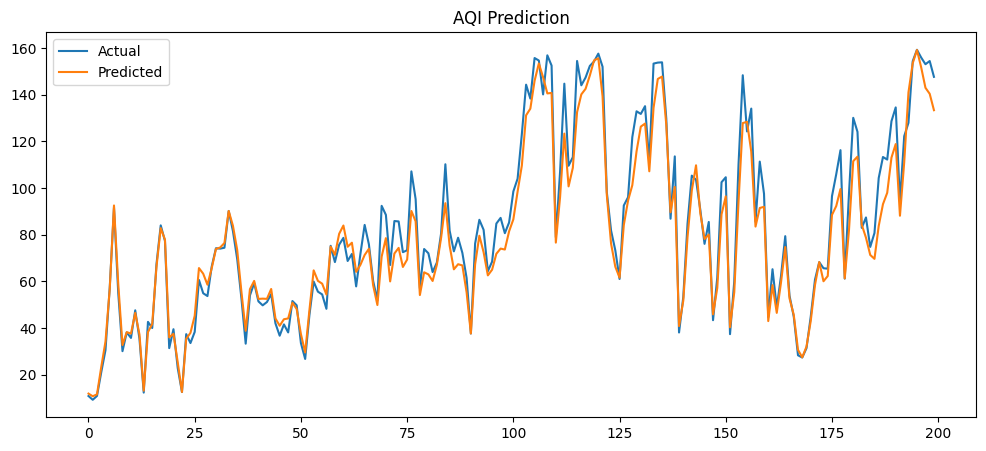

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("AQI Prediction")
plt.show()

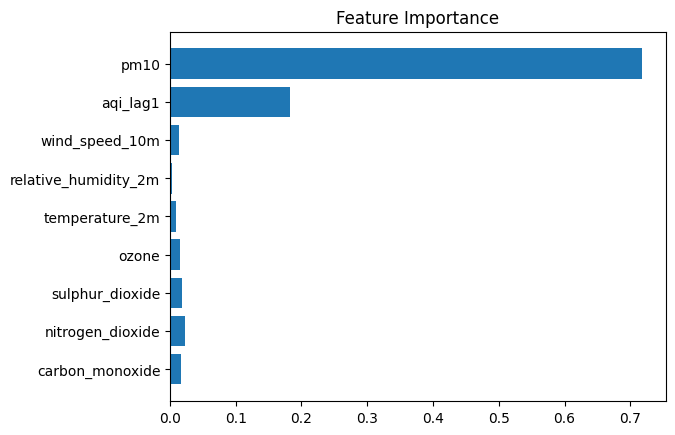

In [22]:
importance = model.feature_importances_

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [23]:
import joblib

joblib.dump(model, 'aqi_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(df_daily, 'data.pkl')  

['data.pkl']